## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.preprocessing import RobustScaler, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, RocCurveDisplay, make_scorer, get_scorer_names
import lightgbm as lgb
import imblearn
from sklearn.inspection import DecisionBoundaryDisplay, permutation_importance
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

random_seed = 209
# Set plot style
sns.set(style="whitegrid")

## Data Preparation

In [ ]:
# If you work with Google Colaboratory, please run this as well.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/GCI/Final Assignment/data.csv'
df = pd.read_csv(file_path)

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,...,2,3029,3,2,0,0,0,0,3,2023


### Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  PerformanceIndex          1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

### Visualizing Numerical Features

Total numerical features to plot: 33
Skipped 2 constant columns


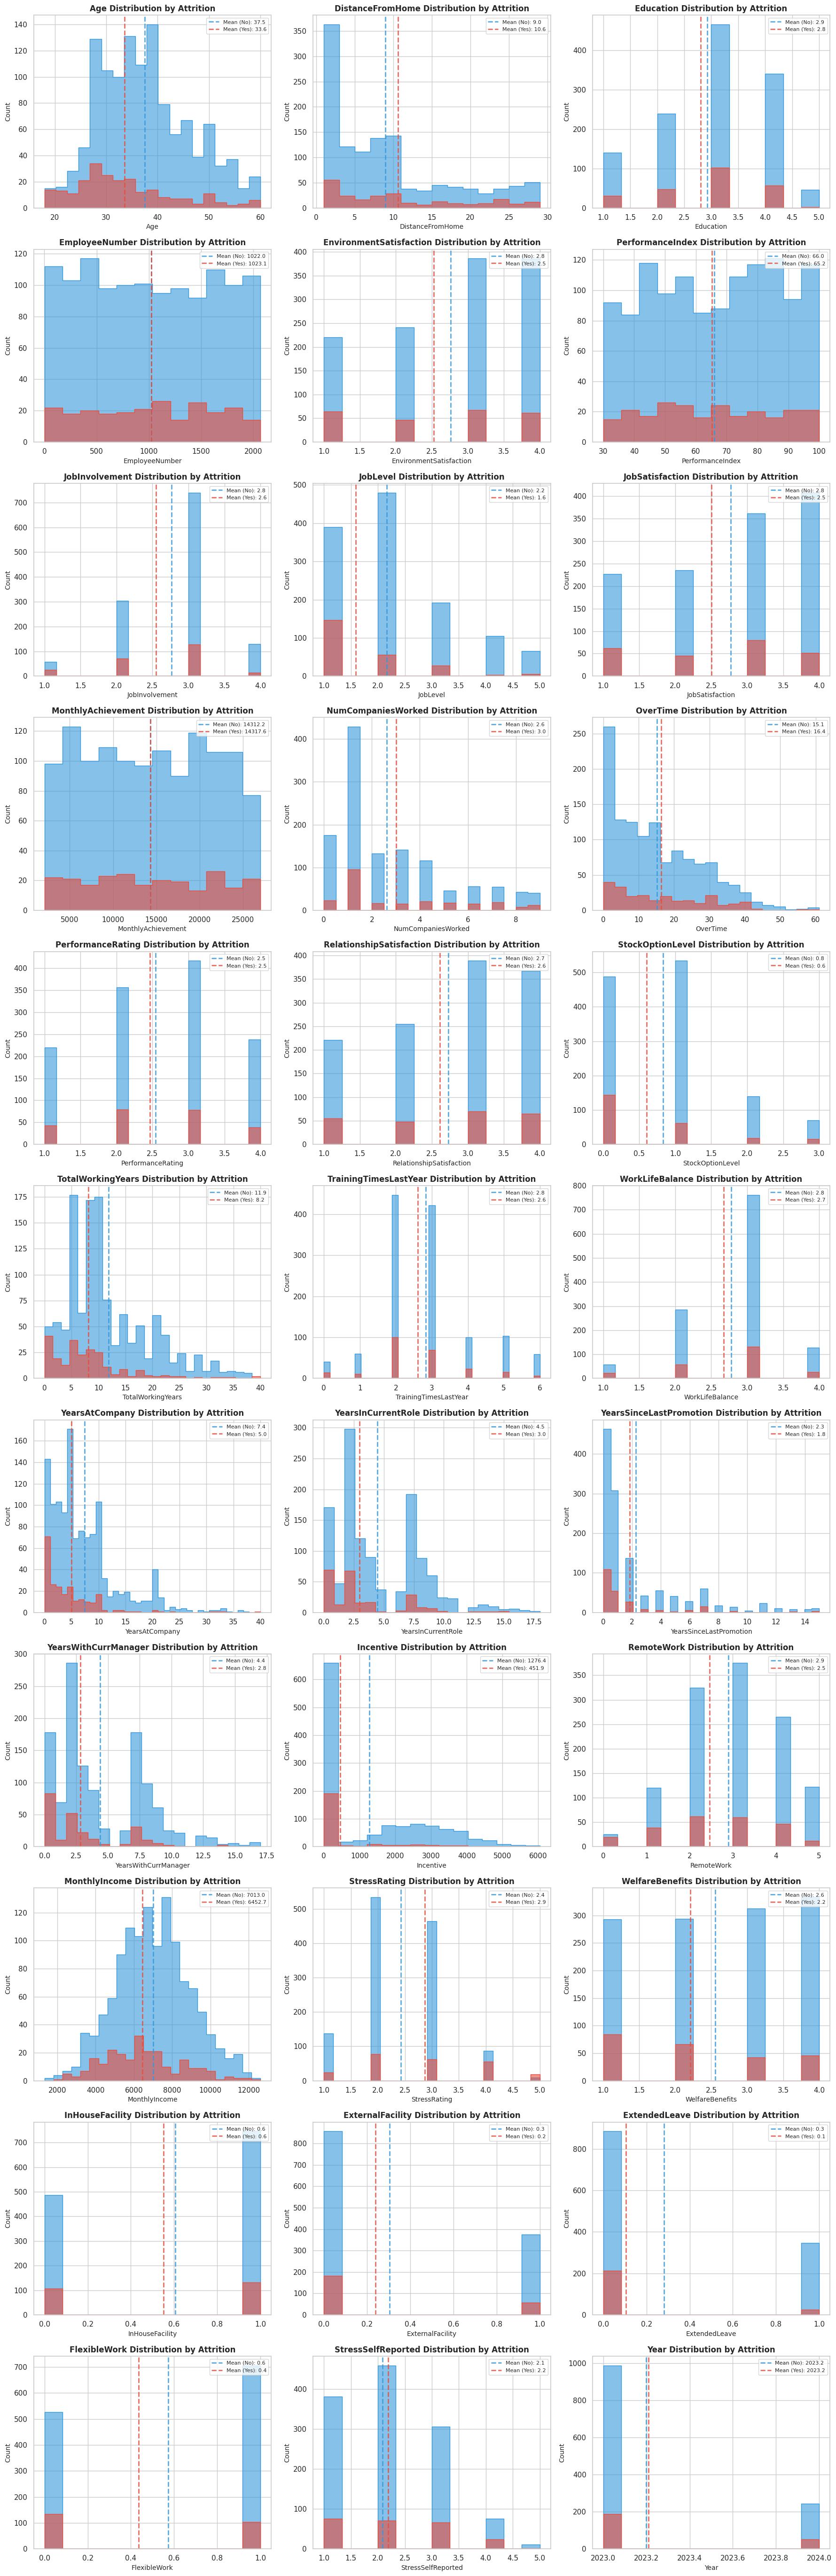

In [ ]:
# Select ALL numerical columns (excluding target)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Attrition' in num_cols:
    num_cols.remove('Attrition')

# Filter out constant columns (zero variance) as they can't be visualized meaningfully
cols_to_plot = [col for col in num_cols if df[col].nunique() > 1]

print(f'Total numerical features to plot: {len(cols_to_plot)}')
print(f'Skipped {len(num_cols) - len(cols_to_plot)} constant columns')

# Calculate grid size
n_cols_to_plot = len(cols_to_plot)
n_rows = math.ceil(n_cols_to_plot / 3)
n_cols_grid = min(3, n_cols_to_plot)

# Plot configurations
fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(18, n_rows * 5))

# Flatten axes if it's 2D
if n_cols_to_plot == 1:
    axes = [axes]
elif n_rows > 1:
    axes = axes.flatten()

# Plot numerical features by Attrition with mean lines
for i, col in enumerate(cols_to_plot):
    # Calculate means for each group
    mean_no = df[df['Attrition'] == 'No'][col].mean()
    mean_yes = df[df['Attrition'] == 'Yes'][col].mean()

    sns.histplot(data=df, x=col, hue='Attrition', hue_order=['Yes', 'No'], kde=False, element='step',
                    ax=axes[i], palette=['#e74c3c', '#3498db'], alpha=0.6)

    # Add vertical lines for means
    axes[i].axvline(mean_no, color='#3498db', linestyle='--', linewidth=2, alpha=0.8,
                    label=f'Mean (No): {mean_no:.1f}')
    axes[i].axvline(mean_yes, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8,
                    label=f'Mean (Yes): {mean_yes:.1f}')

    axes[i].set_title(f'{col} Distribution by Attrition', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend(fontsize=8, loc='upper right')

    # Ensure legend order matches visual: No (blue) first, then Yes (red)
    handles, labels = axes[i].get_legend_handles_labels()
    # Reorder to ensure No comes before Yes
    if len(labels) >= 2:
        # Check current order and swap if needed
        if labels[0] == 'Yes':
            handles = [handles[1], handles[0]]
            labels = [labels[1], labels[0]]
        axes[i].legend(handles, labels, fontsize=8, loc='upper right')

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Visualizing Categorical Features

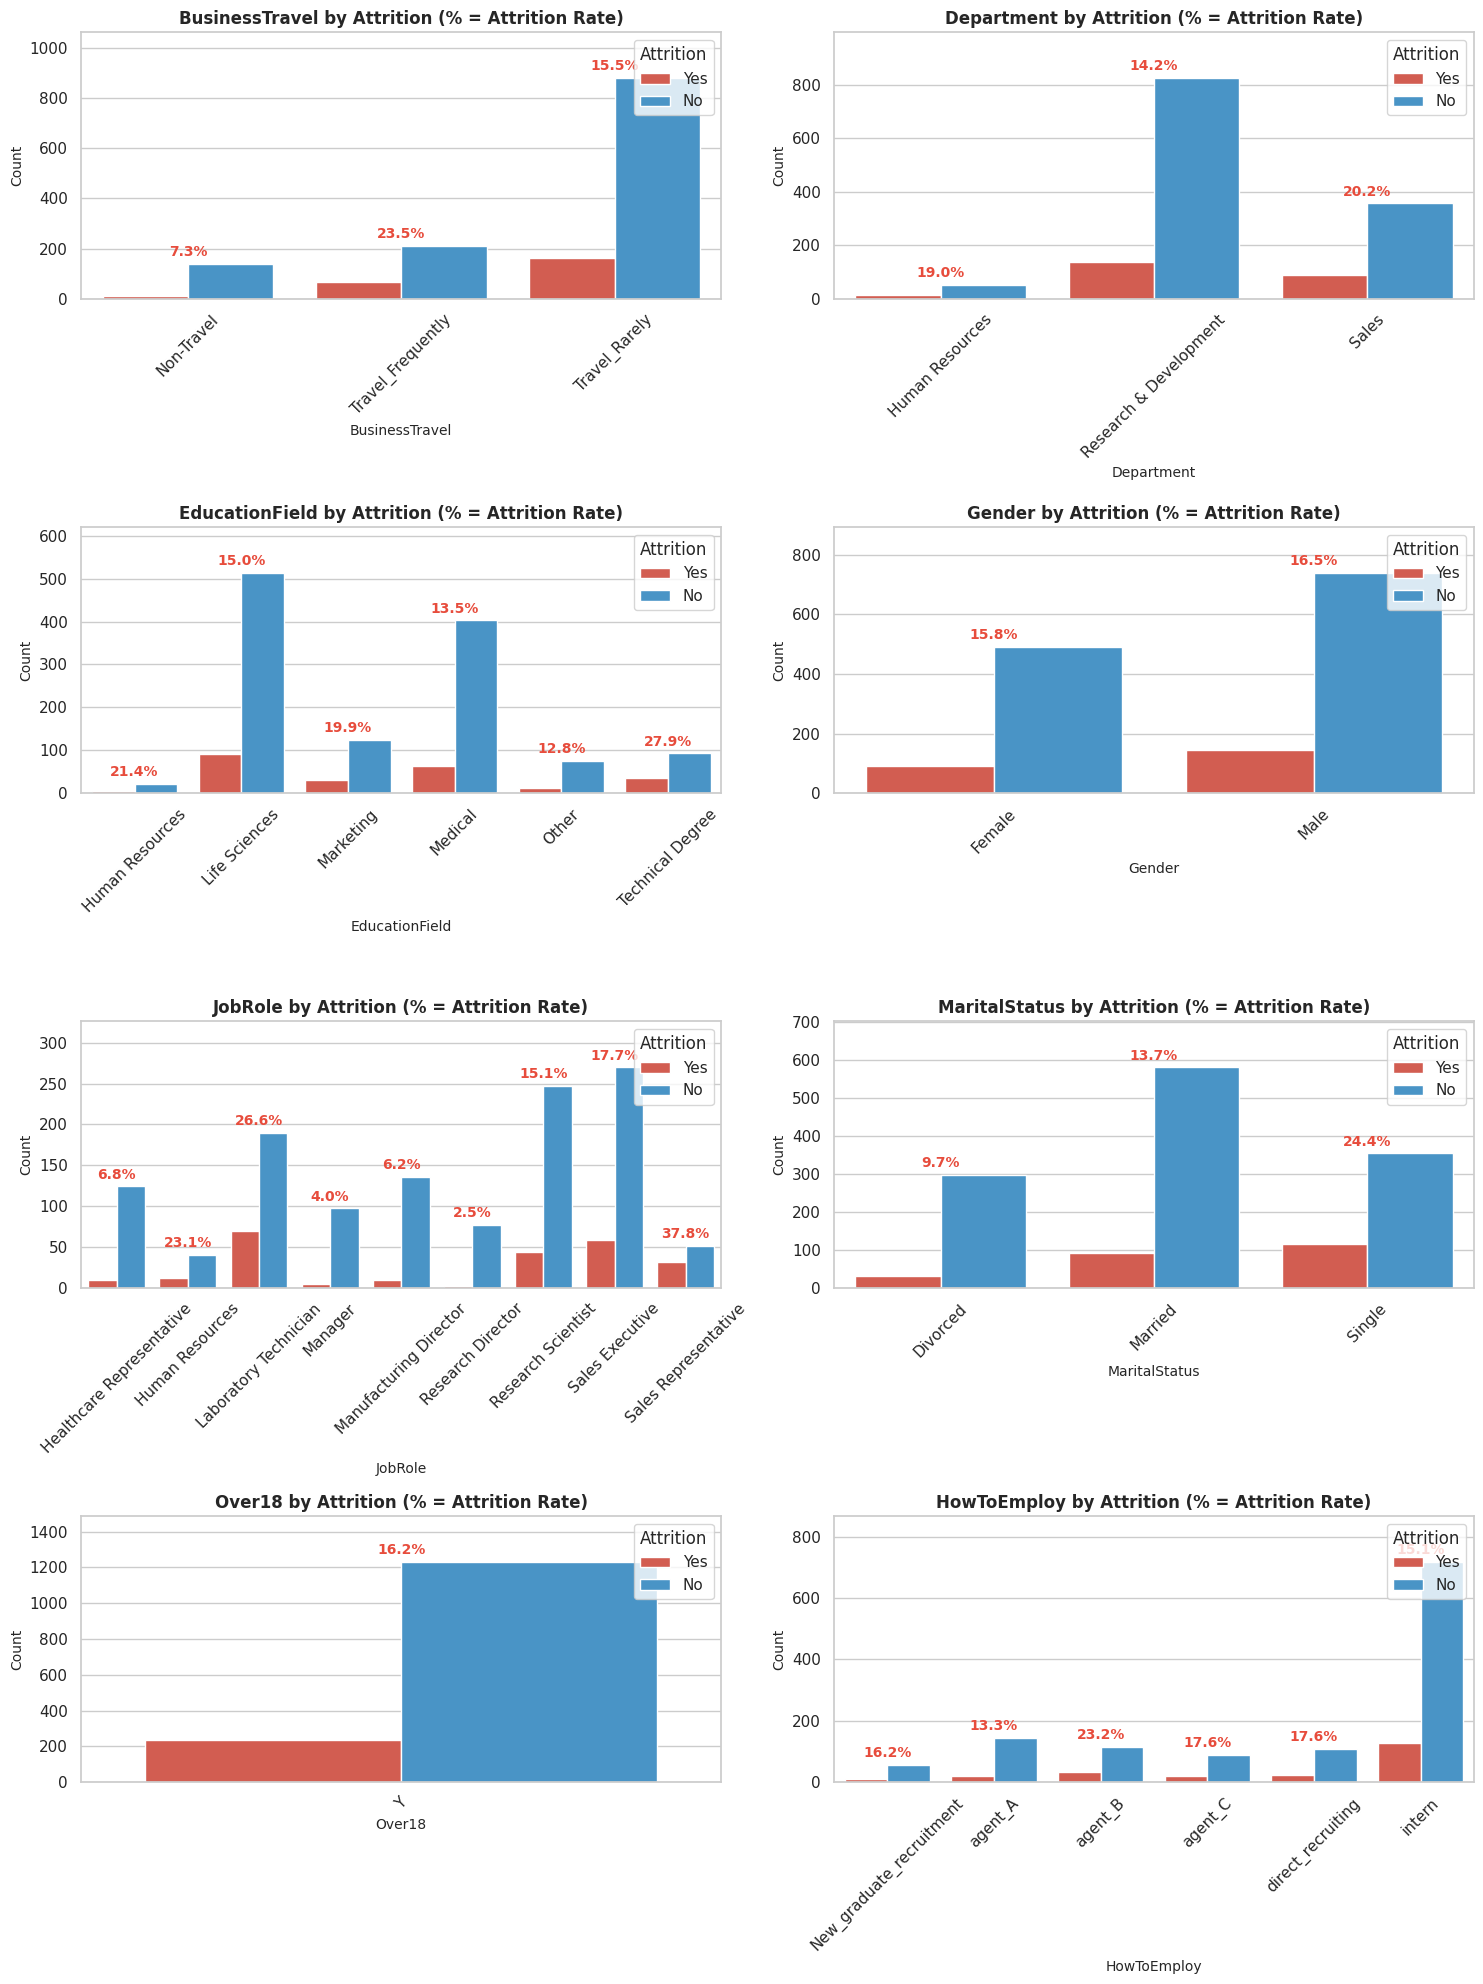

In [ ]:
# Select categorical columns and exclude 'Attrition' (target variable)
obj_cols = df.select_dtypes(include="object").columns
obj_cols = [col for col in obj_cols if col != 'Attrition']

# Calculate grid size dynamically
n_cols_to_plot = len(obj_cols)
n_rows = math.ceil(n_cols_to_plot / 2)
n_cols_grid = min(2, n_cols_to_plot)

# Plot configurations
fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(15, n_rows * 5))

# Flatten axes for easy iteration
if n_cols_to_plot == 1:
    axes = [axes]
elif n_rows > 1:
    axes = axes.flatten()

for i, col in enumerate(obj_cols):
    ax = axes[i]

    # 1. Define fixed order (Crucial to prevent data misalignment)
    # Extract and sort unique categories that have values
    order_list = sorted(df[col].dropna().unique())

    # 2. Create the countplot
    sns.countplot(data=df, x=col, hue='Attrition', hue_order=['Yes', 'No'],
                ax=ax, palette={'No': '#3498db', 'Yes': '#e74c3c'},
                order=order_list) # Explicitly pass the order

    # 3. Aggregate data to calculate attrition rates and determine height
    # Count Yes/No occurrences per category
    counts = df.groupby([col, 'Attrition']).size().unstack(fill_value=0)

    # Get current y-axis limit to calculate relative offset
    y_max_limit = ax.get_ylim()[1]

    # Place text above the bars for each category
    for idx, category in enumerate(order_list):
        if category in counts.index:
            n_yes = counts.loc[category].get('Yes', 0)
            n_no = counts.loc[category].get('No', 0)
            total = n_yes + n_no

            # Calculate attrition rate
            rate = (n_yes / total * 100) if total > 0 else 0

            # Determine Y position for text:
            # Use the height of the taller bar (Yes or No) as the baseline
            max_bar_height = max(n_yes, n_no)
            text_y = max_bar_height + (y_max_limit * 0.02) # Add a small offset

            # Draw text (idx corresponds to the x-axis coordinate due to 'order')
            ax.text(idx, text_y,
                    f'{rate:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color='#e74c3c')

    # Adjust layout settings
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15) # Add extra space at the top for labels
    ax.set_title(f'{col} by Attrition (% = Attrition Rate)', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Attrition', loc='upper right')

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Distribution of Attrition

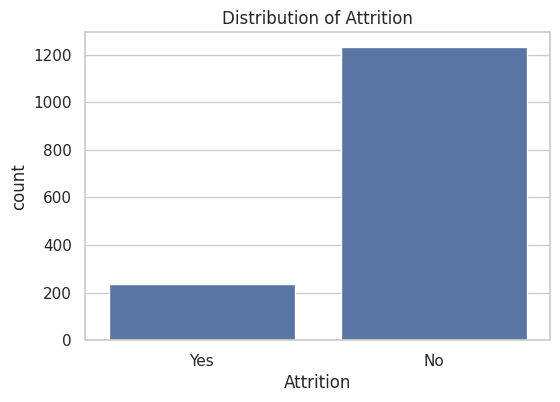

Attrition Rate:
Attrition
No     83.809524
Yes    16.190476
Name: proportion, dtype: float64


In [ ]:
# Visualize Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df)
plt.title('Distribution of Attrition')
plt.show()

# Calculate Attrition Rate
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print("Attrition Rate:")
print(attrition_rate)

## Data Preprocessing

### Descriptive Statistics

In [ ]:
df.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,PerformanceIndex,JobInvolvement,JobLevel,JobSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.895238,9.236735,2.910204,1.0,1022.185034,2.721769,65.891156,2.729932,2.074830,2.728571,...,2.824490,6922.257143,2.499320,2.500000,0.596599,0.293878,0.252381,0.551020,2.104082,2023.200000
std,9.151321,8.129551,1.025259,0.0,602.769132,1.093082,20.329428,0.711561,1.109943,1.102846,...,1.229521,1977.100821,0.883052,1.131124,0.490747,0.455692,0.434526,0.497559,0.949750,0.400136
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,0.000000,1329.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2023.000000
25%,30.000000,2.000000,2.000000,1.0,486.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,2.000000,5542.250000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2023.000000
50%,36.000000,7.000000,3.000000,1.0,1018.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,6814.500000,2.000000,2.000000,1.000000,0.000000,0.000000,1.000000,2.000000,2023.000000
75%,43.000000,14.000000,4.000000,1.0,1554.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,4.000000,8264.750000,3.000000,4.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2023.000000
max,60.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,5.000000,12612.000000,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,5.000000,2024.000000


### Descriptive Statistics for Categorical Features

In [ ]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,HowToEmploy
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,6
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,intern
freq,1232,1043,961,605,886,328,673,1470,846


### Drop Duplicated Values

In [ ]:
df = df.drop_duplicates(subset=['EmployeeNumber'])
df

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,...,2,3029,3,2,0,0,0,0,3,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,Research & Development,23,2,Medical,1,2061,3,...,5,5329,4,1,0,0,0,0,1,2023
1466,39,No,Travel_Rarely,Research & Development,6,1,Medical,1,2062,4,...,1,5175,2,4,1,0,1,1,2,2024
1467,27,No,Travel_Rarely,Research & Development,4,3,Life Sciences,1,2064,2,...,3,5828,3,1,0,0,0,0,3,2023
1468,49,No,Travel_Frequently,Sales,2,3,Medical,1,2065,4,...,2,9420,3,3,1,0,1,0,3,2023


### Drop Irrelevant Features

In [ ]:
df = df.drop(['Over18', 'EmployeeCount', 'StandardHours'], axis=1)
df

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,2,Female,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,2,3,Male,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,4,Male,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,5,4,Female,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,7,1,Male,...,2,3029,3,2,0,0,0,0,3,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,Research & Development,23,2,Medical,2061,3,Male,...,5,5329,4,1,0,0,0,0,1,2023
1466,39,No,Travel_Rarely,Research & Development,6,1,Medical,2062,4,Male,...,1,5175,2,4,1,0,1,1,2,2024
1467,27,No,Travel_Rarely,Research & Development,4,3,Life Sciences,2064,2,Male,...,3,5828,3,1,0,0,0,0,3,2023
1468,49,No,Travel_Frequently,Sales,2,3,Medical,2065,4,Male,...,2,9420,3,3,1,0,1,0,3,2023


## Feature Encoding

In [ ]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'Attrition']
ordinal_encoder = OrdinalEncoder()
df[categorical_cols] = ordinal_encoder.fit_transform(df[categorical_cols])

In [ ]:
attrition = ['Yes', 'No']

def encode_category(x, order):
    return order.index(x)

## Correlation Analysis

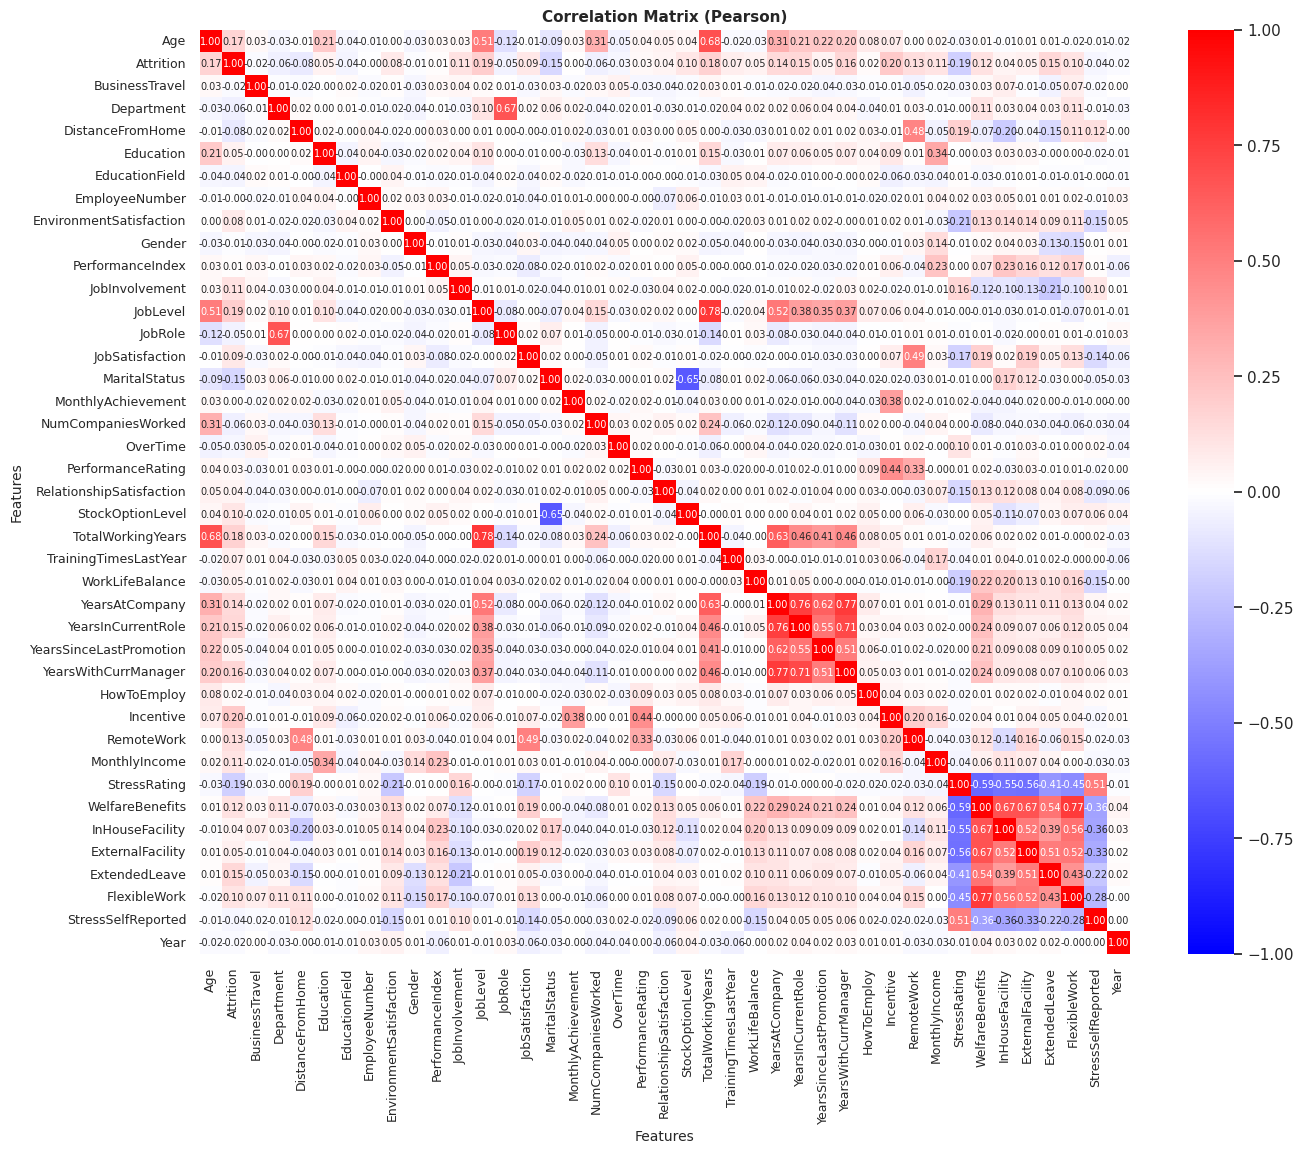

In [ ]:
df_encoded = df.copy()
df_encoded['Attrition'] = df['Attrition'].apply(lambda x: encode_category(x, attrition))

plt.figure(figsize=(15, 12))
ax = sns.heatmap(df_encoded.corr(method='pearson'), vmin=-1, vmax=1, cmap='bwr', annot=True, fmt='.2f', annot_kws={'fontsize': 7})
ax.set_xticklabels(ax.get_xticklabels(), fontdict={'fontsize': 9})
ax.set_yticklabels(ax.get_yticklabels(), fontdict={'fontsize': 9})
plt.title('Correlation Matrix (Pearson)', fontweight='bold', fontsize='11')
plt.xlabel('Features', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.show()

## Resampling Data

In [ ]:
selected_cols = ['TotalWorkingYears','JobLevel']
X = df[selected_cols]
y = df['Attrition']
y_encoded = y.apply(lambda x: encode_category(x, attrition))

ros = imblearn.over_sampling.RandomOverSampler(random_state=random_seed)
rus = imblearn.under_sampling.RandomUnderSampler(random_state=random_seed)
cc = imblearn.under_sampling.ClusterCentroids(random_state=random_seed)

X_resampled, y_resampled = ros.fit_resample(X, y)
y_resampled = y_resampled.to_numpy().reshape(-1, 1)
df_resampled = pd.DataFrame(np.hstack((X_resampled, y_resampled)), columns=X.columns.tolist()+['Attrition'])

X_resampled = df_resampled.drop(['Attrition'], axis=1)
y_resampled = df_resampled['Attrition']
y_resampled_encoded = y_resampled.apply(lambda x: encode_category(x, attrition))

## SVM Model

In [ ]:
cols = ['TotalWorkingYears','JobLevel']
X = df[cols].to_numpy()
y = df['Attrition']
y_encoded = y.apply(lambda x: encode_category(x, attrition))

X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled_encoded, train_size=0.7, stratify=y_resampled_encoded, random_state=209)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.33, stratify=y_val, random_state=209)

standard_scaler = RobustScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_val_scaled = standard_scaler.transform(X_val)
X_test_scaled = standard_scaler.transform(X_test)

cs = [0.01, 0.1, 1, 10, 100]
models = {}
for c in cs:
    model = SVC(class_weight='balanced',kernel='rbf',gamma='auto', C=c, random_state=random_seed, probability=True)
    models[f'SVM (C={c})'] = model

def evaluate_model(models, X_train, y_train, X_val, y_val, X_test, y_test, labels):

    df = pd.DataFrame()
    for (key, model) in models.items():
        model.fit(X_train, y_train)
        y_val_pred_prob = model.predict_proba(X_val)[:, 1]
        y_test_pred_prob = model.predict_proba(X_test)[:, 1]
        y_val_pred = model.predict(X_val)
        y_test_pred = model.predict(X_test)

        val_accuracy = accuracy_score(y_val, y_val_pred)
        val_precision = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_recall = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_auc = roc_auc_score(y_val, y_val_pred_prob)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_auc = roc_auc_score(y_test, y_test_pred_prob)

        metrics = {
            'val_accuracy': val_accuracy,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'test_accuracy': test_accuracy,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1,
            'test_auc': test_auc
        }
        model_df = pd.DataFrame(metrics, index=[key])
        df = pd.concat([df, model_df])

    df = df.round(3)
    return df

df_metrics = evaluate_model(models, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, attrition)
df_metrics

,val_accuracy,val_precision,val_recall,val_f1,val_auc,test_accuracy,test_precision,test_recall,test_f1,test_auc
SVM (C=0.01),0.661,0.662,0.661,0.660,0.697,0.632,0.633,0.632,0.631,0.683
SVM (C=0.1),0.669,0.670,0.669,0.669,0.705,0.657,0.657,0.657,0.657,0.667
SVM (C=1),0.682,0.682,0.682,0.682,0.696,0.669,0.669,0.669,0.669,0.672
SVM (C=10),0.682,0.682,0.682,0.682,0.710,0.669,0.669,0.669,0.669,0.677
SVM (C=100),0.680,0.680,0.680,0.680,0.697,0.674,0.674,0.674,0.674,0.668


[[165  77]
 [ 77 165]]
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       242
           1       0.68      0.68      0.68       242

    accuracy                           0.68       484
   macro avg       0.68      0.68      0.68       484
weighted avg       0.68      0.68      0.68       484



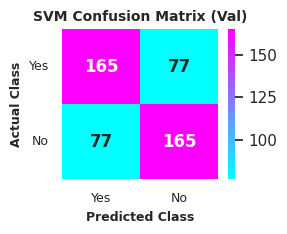


[[81 39]
 [40 79]]
              precision    recall  f1-score   support

           0       0.67      0.68      0.67       120
           1       0.67      0.66      0.67       119

    accuracy                           0.67       239
   macro avg       0.67      0.67      0.67       239
weighted avg       0.67      0.67      0.67       239



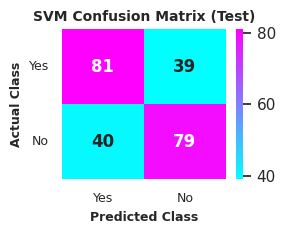

In [ ]:
def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(3, 2.5))
    p = sns.heatmap(cm, annot=True, fmt='d', annot_kws={'fontweight':'bold'}, cmap='cool',
                    xticklabels=class_names, yticklabels=class_names)
    p.set_xticklabels(p.get_xticklabels(), rotation=0, fontsize=9)
    p.set_yticklabels(p.get_yticklabels(), rotation=0, fontsize=9)
    plt.xlabel('Predicted Class', fontweight='bold', fontsize=9)
    plt.ylabel('Actual Class', fontweight='bold', fontsize=9)
    plt.title(title, fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()

model = SVC(class_weight='balanced',kernel='rbf',gamma='auto', C=10, random_state=random_seed, probability=True)
model.fit(X_train_scaled, y_train)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
cm_val = confusion_matrix(y_val, y_val_pred)
plot_confusion_matrix(cm_val, attrition, 'SVM Confusion Matrix (Val)')
print()
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
cm_test = confusion_matrix(y_test, y_test_pred)
plot_confusion_matrix(cm_test, attrition, 'SVM Confusion Matrix (Test)')

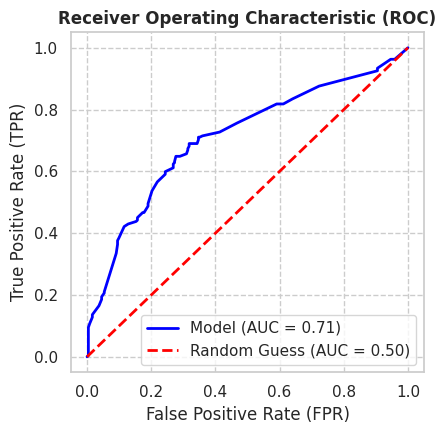

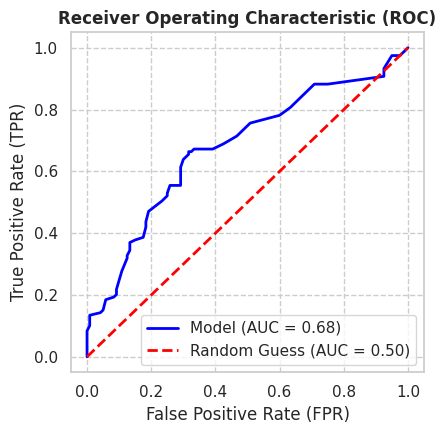

In [ ]:
def plot_roc_curve(fpr, tpr, roc_auc):
    plt.figure(figsize=(4.5, 4.5))
    x_min, x_max, y_min, y_max = -0.05, 1.05, -0.05, 1.05
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'Model (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
    plt.xticks(np.arange(0, 1.1, 0.2))
    plt.yticks(np.arange(0, 1.1, 0.2))
    plt.xlim([x_min, x_max])
    plt.ylim([y_min, y_max])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)', fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.grid(linestyle='--')
    plt.show()

y_val_pred_prob = model.predict_proba(X_val_scaled)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_prob[:, 1])
roc_auc_val = auc(fpr_val, tpr_val)
plot_roc_curve(fpr_val, tpr_val, roc_auc_val)

y_test_pred_prob = model.predict_proba(X_test_scaled)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob[:, 1])
roc_auc_test = auc(fpr_test, tpr_test)
plot_roc_curve(fpr_test, tpr_test, roc_auc_test)

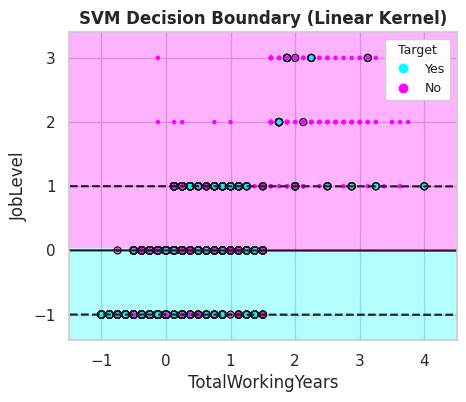

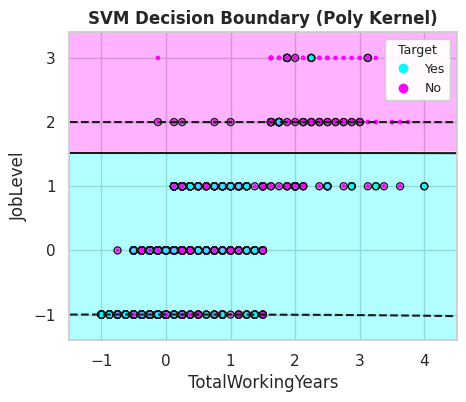

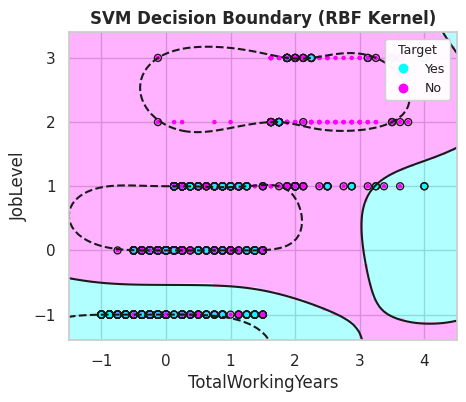

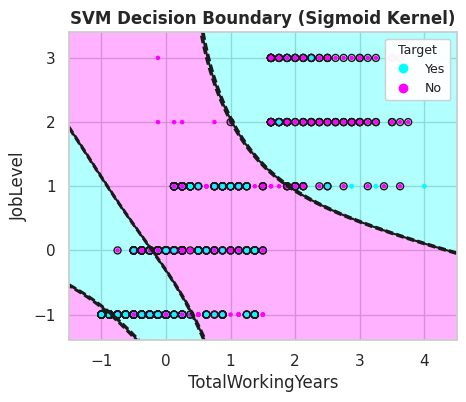

In [ ]:
def plot_svm_decision_boundary(X, y, cols, classes, kernel, titletext, support_vectors=True):
    clf = SVC(kernel=kernel).fit(X, y)
    fig, ax = plt.subplots(figsize=(5, 4))

    common_params = {'estimator': clf, 'X': X, 'ax': ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method='predict',
        plot_method='pcolormesh',
        alpha=0.3,
        cmap='cool',
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method='decision_function',
        plot_method='contour',
        levels=[-1, 0, 1],
        colors=['k', 'k', 'k'],
        linestyles=['--', '-', '--'],
    )

    if support_vectors:
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=25,
            facecolors='none',
            edgecolors='k',
            linewidths=1,
        )

    legend_fontsize = 9
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=5, edgecolors='face', cmap='cool')
    ax.legend(*scatter.legend_elements(), loc='upper right', title='Classes', fontsize=legend_fontsize)
    ax.set_title(titletext, fontweight='bold')

    ax.set_xlabel(cols[0])
    ax.set_ylabel(cols[1])

    color_handles, _ = scatter.legend_elements()
    color_legend = plt.legend(color_handles, classes,
                              title='Target',
                              loc='upper right',
                              title_fontsize=legend_fontsize, fontsize=legend_fontsize)
    plt.gca().add_artist(color_legend)

    x_min, x_max, y_min, y_max = X[:, 0].min(), X[:, 0].max(), X[:, 1].min(), X[:, 1].max()
    x_range, y_range = x_max - x_min, y_max - y_min
    x_lim = [x_min - 0.1 * x_range, x_max + 0.1 * x_range]
    y_lim = [y_min - 0.1 * y_range, y_max + 0.1 * y_range]
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)

    plt.show()
    print()
plot_svm_decision_boundary(X_train_scaled, y_train, cols, attrition, 'linear', 'SVM Decision Boundary (Linear Kernel)')
plot_svm_decision_boundary(X_train_scaled, y_train, cols, attrition, 'poly', 'SVM Decision Boundary (Poly Kernel)')
plot_svm_decision_boundary(X_train_scaled, y_train, cols, attrition, 'rbf', 'SVM Decision Boundary (RBF Kernel)')
plot_svm_decision_boundary(X_train_scaled, y_train, cols, attrition, 'sigmoid', 'SVM Decision Boundary (Sigmoid Kernel)')

## KNN Model

In [ ]:
selected_cols = ['TotalWorkingYears','JobLevel']
X = df[selected_cols]
y = df['Attrition']
y_encoded = y.apply(lambda x: encode_category(x, attrition))

ros = imblearn.over_sampling.RandomOverSampler(random_state=random_seed)
rus = imblearn.under_sampling.RandomUnderSampler(random_state=random_seed)
cc = imblearn.under_sampling.ClusterCentroids(random_state=random_seed)

X_resampled, y_resampled = ros.fit_resample(X, y)
y_resampled = y_resampled.to_numpy().reshape(-1, 1)
df_resampled = pd.DataFrame(np.hstack((X_resampled, y_resampled)), columns=X.columns.tolist()+['Attrition'])

X_resampled = df_resampled.drop(['Attrition'], axis=1)
y_resampled = df_resampled['Attrition']
y_resampled_encoded = y_resampled.apply(lambda x: encode_category(x, attrition))

In [ ]:
cols = ['TotalWorkingYears','JobLevel']
X = df[cols].to_numpy()
y = df['Attrition']
y_encoded = y.apply(lambda x: encode_category(x, attrition))

X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled_encoded, train_size=0.7, stratify=y_resampled_encoded, random_state=209)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.33, stratify=y_val, random_state=209)

standard_scaler = RobustScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_val_scaled = standard_scaler.transform(X_val)
X_test_scaled = standard_scaler.transform(X_test)

ks = range(1, 11, 2)
models = {}
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    models[f'KNN (K={k})'] = model

def evaluate_model(models, X_train, y_train, X_val, y_val, X_test, y_test, labels):

    df = pd.DataFrame()
    for (key, model) in models.items():
        model.fit(X_train, y_train)
        y_val_pred_prob = model.predict_proba(X_val)[:, 1]
        y_test_pred_prob = model.predict_proba(X_test)[:, 1]
        y_val_pred = model.predict(X_val)
        y_test_pred = model.predict(X_test)

        val_accuracy = accuracy_score(y_val, y_val_pred)
        val_precision = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_recall = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_auc = roc_auc_score(y_val, y_val_pred_prob)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_auc = roc_auc_score(y_test, y_test_pred_prob)

        metrics = {
            'val_accuracy': val_accuracy,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'test_accuracy': test_accuracy,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1,
            'test_auc': test_auc
        }
        model_df = pd.DataFrame(metrics, index=[key])
        df = pd.concat([df, model_df])

    df = df.round(3)
    return df

df_metrics = evaluate_model(models, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, attrition)
df_metrics

,val_accuracy,val_precision,val_recall,val_f1,val_auc,test_accuracy,test_precision,test_recall,test_f1,test_auc
KNN (K=1),0.585,0.592,0.585,0.576,0.585,0.632,0.635,0.631,0.629,0.631
KNN (K=3),0.605,0.610,0.605,0.602,0.658,0.674,0.675,0.673,0.673,0.708
KNN (K=5),0.572,0.582,0.572,0.559,0.660,0.619,0.624,0.619,0.615,0.685
KNN (K=7),0.618,0.634,0.618,0.606,0.700,0.632,0.642,0.631,0.625,0.696
KNN (K=9),0.610,0.623,0.610,0.598,0.685,0.615,0.621,0.615,0.609,0.691


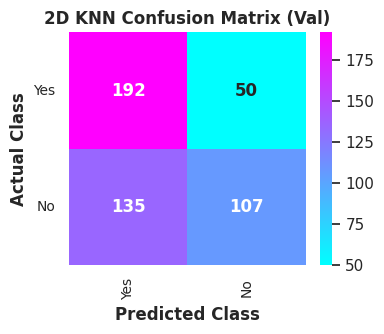

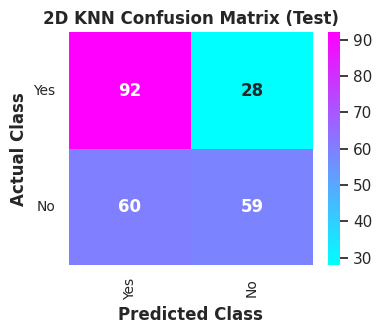

In [ ]:
def plot_confusion_matrix(cm, class_names, figsize, title, cmap, filename='cm'):
    plt.figure(figsize=figsize)
    p = sns.heatmap(cm, annot=True, fmt='d', annot_kws={'fontweight':'bold'}, cmap=cmap,
                    xticklabels=class_names, yticklabels=class_names)
    p.set_xticklabels(p.get_xticklabels(), rotation=90, fontsize = 10)
    p.set_yticklabels(p.get_yticklabels(), rotation=0, fontsize = 10)
    plt.xlabel('Predicted Class', fontweight='bold')
    plt.ylabel('Actual Class', fontweight='bold')
    plt.title(title, fontweight='bold')
    plt.tight_layout()
    # plt.savefig(os.path.join(OUTPUT_DIR, f'{filename}.png'))
    plt.show()

model = models['KNN (K=7)']
model.fit(X_train_scaled, y_train)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)
cm_val = confusion_matrix(y_val, y_val_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
plot_confusion_matrix(cm_val, attrition, (4, 3.5), '2D KNN Confusion Matrix (Val)', 'cool')
plot_confusion_matrix(cm_test, attrition, (4, 3.5), '2D KNN Confusion Matrix (Test)', 'cool')

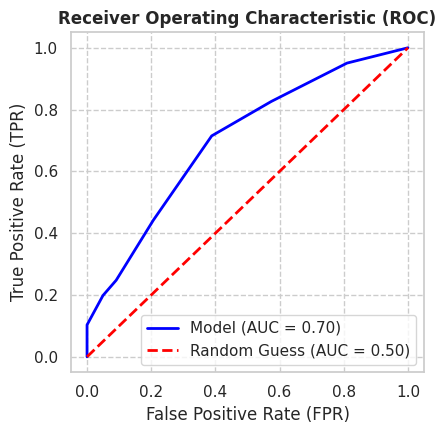

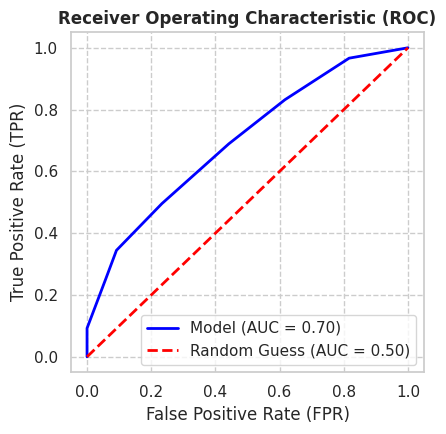

In [ ]:
def plot_roc_curve(fpr, tpr, roc_auc):
    plt.figure(figsize=(4.5, 4.5))
    x_min, x_max, y_min, y_max = -0.05, 1.05, -0.05, 1.05
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'Model (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
    plt.xticks(np.arange(0, 1.1, 0.2))
    plt.yticks(np.arange(0, 1.1, 0.2))
    plt.xlim([x_min, x_max])
    plt.ylim([y_min, y_max])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)', fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.grid(linestyle='--')
    plt.show()

y_val_pred_prob = model.predict_proba(X_val_scaled)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_prob[:, 1])
roc_auc_val = auc(fpr_val, tpr_val)
plot_roc_curve(fpr_val, tpr_val, roc_auc_val)

y_test_pred_prob = model.predict_proba(X_test_scaled)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob[:, 1])
roc_auc_test = auc(fpr_test, tpr_test)
plot_roc_curve(fpr_test, tpr_test, roc_auc_test)

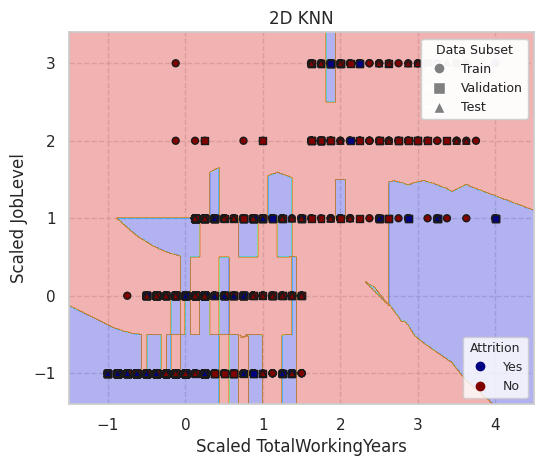

In [ ]:
def visualize_2d_knn_with_splits(X_train, y_train, X_val, y_val, X_test, y_test, model, cols, target_names, title, cmap):
    # Combine all data for consistent plot limits
    X_all = np.vstack((X_train, X_val, X_test))
    x_range = X_all[:, 0].max() - X_all[:, 0].min()
    y_range = X_all[:, 1].max() - X_all[:, 1].min()
    x_min, x_max = X_all[:, 0].min() - 0.1*x_range, X_all[:, 0].max() + 0.1*x_range
    y_min, y_max = X_all[:, 1].min() - 0.1*y_range, X_all[:, 1].max() + 0.1*y_range

    # Create the meshgrid for the decision surface
    xx, yy = np.meshgrid(np.arange(x_min, x_max, x_range/500),
                       np.arange(y_min, y_max, y_range/500))

    # Predict on the meshgrid to get decision regions
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 6))
    plt.gca().set_aspect('equal')

    # Plot the decision surface
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    marker_size = 25
    edge_color = 'k'
    line_width = 1
    # Training data: circles
    scatter_train = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap, linewidths=line_width,
                                s=marker_size, edgecolors=edge_color, marker='o')
    # Validation data: squares
    plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=cmap, linewidths=line_width,
                s=marker_size, edgecolors=edge_color, marker='s')

    # Test data: triangles
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap, linewidths=line_width,
                s=marker_size, edgecolors=edge_color, marker='^')

    plt.xlabel(f'Scaled {cols[0]}')
    plt.ylabel(f'Scaled {cols[1]}')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.6)

    legend_fontsize = 9
    # 1. Legend for Attrition (colors)
    color_handles, _ = scatter_train.legend_elements()
    color_legend = plt.legend(color_handles, target_names,
                              title='Attrition',
                              loc='lower right',
                              title_fontsize=legend_fontsize, fontsize=legend_fontsize)
    plt.gca().add_artist(color_legend)

    # 2. Legend for Data Subsets (shapes)
    shape_handles = [
        Line2D([0], [0], marker='o', color='w', label='Train', markersize=8, markerfacecolor='gray'),
        Line2D([0], [0], marker='s', color='w', label='Validation', markersize=8, markerfacecolor='gray'),
        Line2D([0], [0], marker='^', color='w', label='Test', markersize=8, markerfacecolor='gray')
    ]
    shape_legend = plt.legend(handles=shape_handles, title='Data Subset', loc='upper right',
                              title_fontsize=legend_fontsize, fontsize=legend_fontsize)
    plt.gca().add_artist(shape_legend)

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()

visualize_2d_knn_with_splits(
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    X_test_scaled, y_test,
    model, cols, attrition,
    title='2D KNN', cmap='jet'
)

## Random Forest

In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']
y_encoded = y.apply(lambda x: encode_category(x, attrition))

ros = imblearn.over_sampling.RandomOverSampler(random_state=random_seed)
rus = imblearn.under_sampling.RandomUnderSampler(random_state=random_seed)
cc = imblearn.under_sampling.ClusterCentroids(random_state=random_seed)

X_resampled, y_resampled = ros.fit_resample(X, y)
y_resampled = y_resampled.to_numpy().reshape(-1, 1)
df_resampled = pd.DataFrame(np.hstack((X_resampled, y_resampled)), columns=X.columns.tolist()+['Attrition'])

X_resampled = df_resampled.drop(['Attrition'], axis=1)
y_resampled = df_resampled['Attrition']
y_resampled_encoded = y_resampled.apply(lambda x: encode_category(x, attrition))

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled_encoded, train_size=0.7, stratify=y_resampled_encoded, random_state=209)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.33, stratify=y_val, random_state=209)

standard_scaler = RobustScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_val_scaled = standard_scaler.transform(X_val)
X_test_scaled = standard_scaler.transform(X_test)


n_trees = [50, 100, 200, 300, 500]
models = {}

for n in n_trees:
    model = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced',
        max_depth=None,
        random_state=209,
        min_samples_split=2,
        min_samples_leaf=1,
    )
    models[f'RF (n={n})'] = model

def evaluate_model(models, X_train, y_train, X_val, y_val, X_test, y_test, labels):

    df = pd.DataFrame()
    for (key, model) in models.items():
        model.fit(X_train, y_train)
        y_val_pred_prob = model.predict_proba(X_val)[:, 1]
        y_test_pred_prob = model.predict_proba(X_test)[:, 1]
        y_val_pred = model.predict(X_val)
        y_test_pred = model.predict(X_test)

        val_accuracy = accuracy_score(y_val, y_val_pred)
        val_precision = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_recall = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)
        val_auc = roc_auc_score(y_val, y_val_pred_prob)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_auc = roc_auc_score(y_test, y_test_pred_prob)

        metrics = {
            'val_accuracy': val_accuracy,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'test_accuracy': test_accuracy,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1,
            'test_auc': test_auc
        }
        model_df = pd.DataFrame(metrics, index=[key])
        df = pd.concat([df, model_df])

    df = df.round(3)
    return df

df_metrics = evaluate_model(models, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, attrition)
df_metrics

,val_accuracy,val_precision,val_recall,val_f1,val_auc,test_accuracy,test_precision,test_recall,test_f1,test_auc
RF (n=50),0.975,0.976,0.975,0.975,0.999,0.975,0.975,0.975,0.975,0.999
RF (n=100),0.977,0.978,0.977,0.977,0.999,0.987,0.988,0.987,0.987,0.999
RF (n=200),0.977,0.978,0.977,0.977,0.999,0.987,0.988,0.987,0.987,0.999
RF (n=300),0.975,0.976,0.975,0.975,0.999,0.987,0.988,0.987,0.987,1.000
RF (n=500),0.967,0.968,0.967,0.967,0.999,0.983,0.983,0.983,0.983,0.999


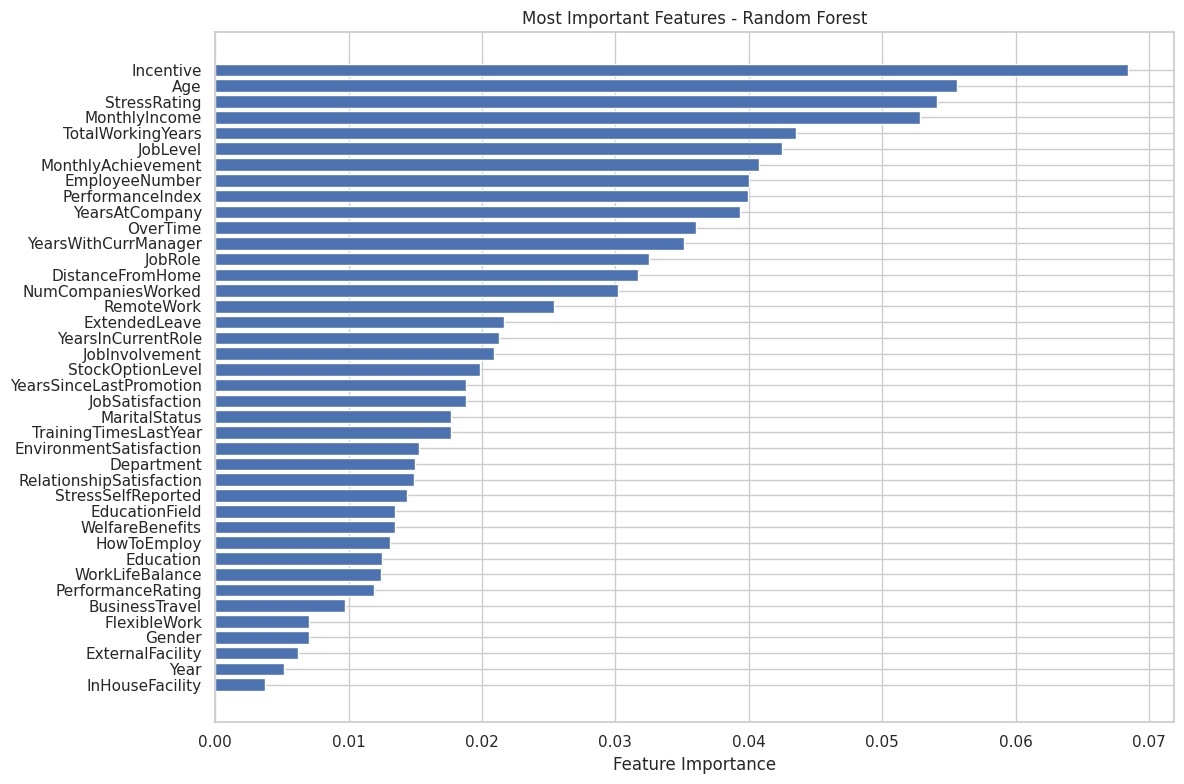


Detail:
Incentive: 0.0684
Age: 0.0556
StressRating: 0.0541
MonthlyIncome: 0.0528
TotalWorkingYears: 0.0435
JobLevel: 0.0425
MonthlyAchievement: 0.0408
EmployeeNumber: 0.0400
PerformanceIndex: 0.0399
YearsAtCompany: 0.0393
OverTime: 0.0360
YearsWithCurrManager: 0.0352
JobRole: 0.0325
DistanceFromHome: 0.0317
NumCompaniesWorked: 0.0302
RemoteWork: 0.0254
ExtendedLeave: 0.0217
YearsInCurrentRole: 0.0212
JobInvolvement: 0.0209
StockOptionLevel: 0.0199
YearsSinceLastPromotion: 0.0188
JobSatisfaction: 0.0188
MaritalStatus: 0.0177
TrainingTimesLastYear: 0.0177
EnvironmentSatisfaction: 0.0153
Department: 0.0150
RelationshipSatisfaction: 0.0149
StressSelfReported: 0.0144
EducationField: 0.0135
WelfareBenefits: 0.0135
HowToEmploy: 0.0131
Education: 0.0125
WorkLifeBalance: 0.0124
PerformanceRating: 0.0119
BusinessTravel: 0.0097
FlexibleWork: 0.0071
Gender: 0.0070
ExternalFacility: 0.0062
Year: 0.0052
InHouseFacility: 0.0037


In [ ]:
rf_model = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_depth=None,
        random_state=209,
        min_samples_split=2,
        min_samples_leaf=1,
    )

rf_model.fit(X_train_scaled, y_train)

# Make prediction
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Plot feature importance
plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame({
    'feature': X_resampled.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.title('Most Important Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Display top features
print("\nDetail:")
for i, row in feature_importance.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")


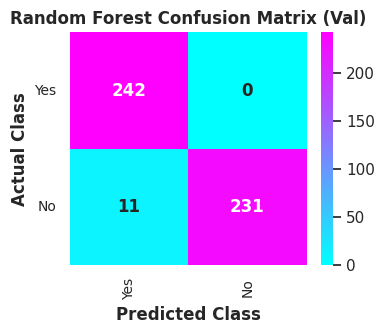

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       242
           1       1.00      0.95      0.98       242

    accuracy                           0.98       484
   macro avg       0.98      0.98      0.98       484
weighted avg       0.98      0.98      0.98       484



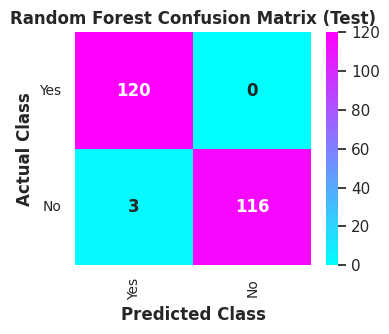

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       120
           1       1.00      0.97      0.99       119

    accuracy                           0.99       239
   macro avg       0.99      0.99      0.99       239
weighted avg       0.99      0.99      0.99       239



In [ ]:
y_val_pred = rf_model.predict(X_val_scaled)
y_test_pred = rf_model.predict(X_test_scaled)
cm_val = confusion_matrix(y_val, y_val_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
plot_confusion_matrix(cm_val, attrition, (4, 3.5), 'Random Forest Confusion Matrix (Val)', 'cool')
print(classification_report(y_val, y_val_pred))
plot_confusion_matrix(cm_test, attrition, (4, 3.5), 'Random Forest Confusion Matrix (Test)', 'cool')
print(classification_report(y_test, y_test_pred))

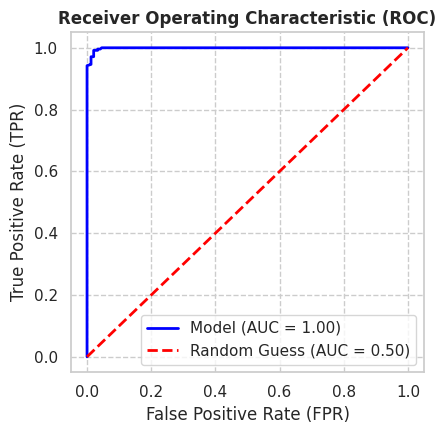

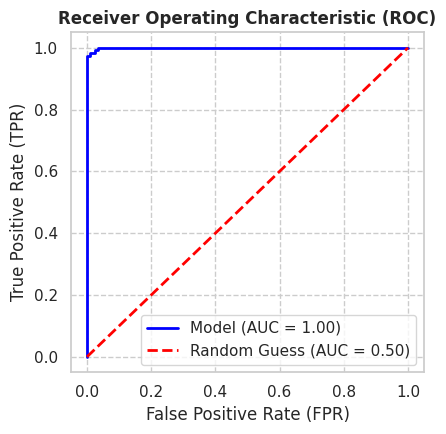

In [ ]:
def plot_roc_curve(fpr, tpr, roc_auc):
    plt.figure(figsize=(4.5, 4.5))
    x_min, x_max, y_min, y_max = -0.05, 1.05, -0.05, 1.05
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'Model (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
    plt.xticks(np.arange(0, 1.1, 0.2))
    plt.yticks(np.arange(0, 1.1, 0.2))
    plt.xlim([x_min, x_max])
    plt.ylim([y_min, y_max])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)', fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.grid(linestyle='--')
    plt.show()

y_val_pred_prob = model.predict_proba(X_val_scaled)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_prob[:, 1])
roc_auc_val = auc(fpr_val, tpr_val)
plot_roc_curve(fpr_val, tpr_val, roc_auc_val)

y_test_pred_prob = model.predict_proba(X_test_scaled)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob[:, 1])
roc_auc_test = auc(fpr_test, tpr_test)
plot_roc_curve(fpr_test, tpr_test, roc_auc_test)

## References:

*   [https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/](https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/)
*   [https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbors-with-python-ml/](https://)
*   [https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/](https://)
*   [https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html](https://)


*   [https://chatgpt.com/share/69352dcb-7f30-800c-a762-0adb313c2741](https://)
*   [https://instepuk.com/article/employee-attrition/](https://)


*   [https://primalogik.com/blog/employee-attrition-definitive-guide/#:~:text=As%20a%20result%2C%20the%20team,are%20leaving%20without%20being%20replaced](https://)
*   [https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://)






